# 1. Introducción
 
La relación entre la masa ($M$) y la luminosidad ($L$) de las estrellas es un tema fundamental en la astrofísica. Comprender cómo varía la luminosidad en función de la masa permite inferir propiedades físicas y evolutivas de las estrellas.
 
El objetivo de este cuaderno es implementar **regresión lineal** desde cero, utilizando únicamente **NumPy** y **Matplotlib**, para modelar la relación entre masa y luminosidad en un conjunto de datos astronómicos.
 
La implementación manual de la regresión lineal es esencial para comprender los fundamentos matemáticos y computacionales detrás de los algoritmos de aprendizaje automático. Evitaremos el uso de cualquier librería de machine learning o métodos de optimización automáticos, siguiendo un enfoque académico y riguroso.
 
A lo largo del cuaderno, derivaremos todas las fórmulas, implementaremos los gradientes manualmente y analizaremos el comportamiento del modelo sobre el dataset propuesto.

> **Nota para el usuario:**
>
> Este cuaderno requiere las librerías `numpy` y `matplotlib` para ejecutarse correctamente. Si alguna de ellas no está instalada en tu entorno, ejecuta la siguiente celda para instalar las dependencias antes de continuar.

In [ ]:
# Instalación de librerías necesarias (ejecutar solo si es necesario)
!pip install numpy
!pip install matplotlib

# 2. Visualización del Dataset
 
A continuación se presenta el conjunto de datos astronómicos que relaciona la masa ($M$) y la luminosidad ($L$) de diferentes estrellas.
 
La visualización inicial permite analizar la posible relación lineal entre ambas variables y discutir su significado físico.
 
**Masa ($M$) [unidades solares]:**
0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4
 
**Luminosidad ($L$) [unidades solares]:**
0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0
 
La relación masa-luminosidad es fundamental en la física estelar, ya que permite estimar la energía emitida por una estrella a partir de su masa.

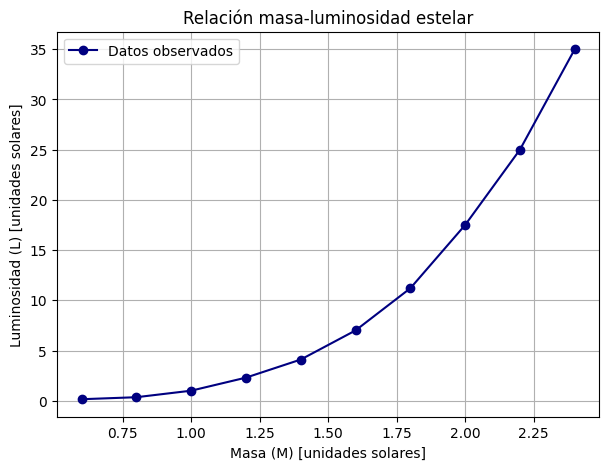

In [33]:
import numpy as np
import matplotlib.pyplot as plt

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])
 
plt.figure(figsize=(7,5))
plt.plot(M, L, 'o-', color='navy', label='Datos observados')
plt.xlabel('Masa (M) [unidades solares]')
plt.ylabel('Luminosidad (L) [unidades solares]')
plt.title('Relación masa-luminosidad estelar')
plt.grid(True)
plt.legend()
plt.show()

**Análisis de la gráfica:**
 
La gráfica muestra una relación creciente entre la masa y la luminosidad de las estrellas. Sin embargo, se observa que el crecimiento no es perfectamente lineal, especialmente para valores altos de masa, lo que sugiere la presencia de una relación física más compleja.
 
En astrofísica, la relación masa-luminosidad suele aproximarse por una ley de potencia, pero en este ejercicio se utilizará un modelo lineal para ilustrar los fundamentos matemáticos y computacionales de la regresión.

# 3. Modelo y Función de Pérdida
 
El modelo de regresión lineal que se utilizará es:
 
$$
\hat{L} = w M + b
$$
 
donde:
- $M$ es la masa de la estrella.
- $L$ es la luminosidad observada.
- $\hat{L}$ es la luminosidad predicha por el modelo.
- $w$ es el parámetro de pendiente.
- $b$ es el sesgo o intercepto.
 
La función de pérdida utilizada será el **error cuadrático medio (MSE)**:
 
$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^m (\hat{L}^{(i)} - L^{(i)})^2
$$
 
donde $m$ es el número de ejemplos en el dataset.
 
Esta función penaliza las diferencias entre las predicciones del modelo y los valores reales observados.

In [34]:
def predict(M, w, b):
    """Predice luminosidad usando el modelo lineal."""
    return w * M + b
 
def compute_cost(M, L, w, b):
    """Calcula el error cuadrático medio (MSE) para los parámetros dados."""
    m = len(M)
    L_hat = predict(M, w, b)
    cost = (1/(2*m)) * np.sum((L_hat - L)**2)
    return cost

# 4. Superficie de Costo
 
Para comprender cómo varía la función de pérdida $J(w, b)$ con los parámetros, se evalúa la función en una malla de valores de $w$ y $b$. Esto permite visualizar la superficie de costo y localizar el mínimo global.
 
La exploración se realiza mediante bucles explícitos, sin vectorización, para ilustrar el cálculo manual.

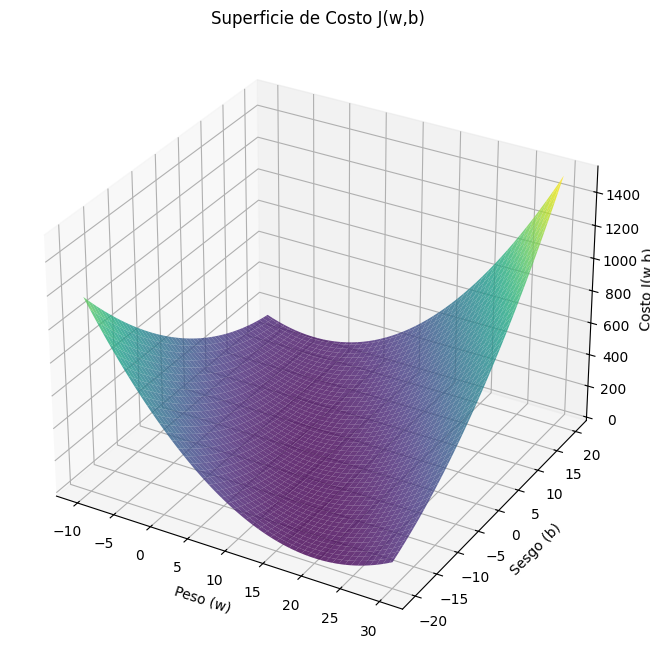

In [35]:
w_range = np.linspace(-10, 30, 100)
b_range = np.linspace(-20, 20, 100)
W, B = np.meshgrid(w_range, b_range)
zs = np.array([compute_cost(M, L, w, b) for w, b in zip(np.ravel(W), np.ravel(B))])
Z = zs.reshape(W.shape)
 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('Peso (w)')
ax.set_ylabel('Sesgo (b)')
ax.set_zlabel('Costo J(w,b)')
plt.title('Superficie de Costo J(w,b)')
plt.show()

**Explicación del mínimo:**
 
La gráfica de la superficie de costo muestra cómo el valor de $J(w, b)$ varía con los parámetros. El mínimo global corresponde a la combinación de $w$ y $b$ que mejor ajusta el modelo a los datos, minimizando el error cuadrático medio.

# 5. Derivación de Gradientes
 
Para minimizar la función de costo $J(w, b)$ mediante descenso por gradiente, es necesario calcular sus derivadas parciales respecto a $w$ y $b$.
 
**Derivadas manuales:**
 
$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^m (\hat{L}^{(i)} - L^{(i)}) M^{(i)}
$$
$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (\hat{L}^{(i)} - L^{(i)})
$$
 
Estas fórmulas se implementan manualmente en Python.

In [36]:
def compute_gradient(M, L, w, b):
    """Calcula los gradientes dJ/dw y dJ/db manualmente."""
    m = len(M)
    L_hat = predict(M, w, b)
    dJ_dw = (1/m) * np.sum((L_hat - L) * M)
    dJ_db = (1/m) * np.sum(L_hat - L)
    return dJ_dw, dJ_db

# 6. Descenso por Gradiente No Vectorizado
 
Se implementa el algoritmo de descenso por gradiente utilizando bucles explícitos, sin vectorización, siguiendo la metodología de los archivos guía.

In [37]:
def gradient_descent_no_vectorized(M, L, w_init, b_init, alpha, num_iters):
    w = w_init
    b = b_init
    m = len(M)
    J_history = []
    for it in range(num_iters):

        L_hat = np.zeros(m)
        for i in range(m):
            L_hat[i] = w * M[i] + b
        dJ_dw = 0.0
        dJ_db = 0.0
        for i in range(m):
            dJ_dw += (L_hat[i] - L[i]) * M[i]
            dJ_db += (L_hat[i] - L[i])
        dJ_dw /= m
        dJ_db /= m

        w = w - alpha * dJ_dw
        b = b - alpha * dJ_db

        cost = (1/(2*m)) * np.sum((L_hat - L)**2)
        J_history.append(cost)
    return w, b, J_history

# 7. Descenso por Gradiente Vectorizado
 
Ahora se implementa el descenso por gradiente utilizando operaciones vectorizadas con NumPy, lo que mejora la eficiencia y claridad del código.

In [38]:
def gradient_descent_vectorized(M, L, w_init, b_init, alpha, num_iters):
    w = w_init
    b = b_init
    J_history = []
    m = len(M)
    for it in range(num_iters):
        L_hat = predict(M, w, b)
        dJ_dw = (1/m) * np.sum((L_hat - L) * M)
        dJ_db = (1/m) * np.sum(L_hat - L)
        w = w - alpha * dJ_dw
        b = b - alpha * dJ_db
        cost = (1/(2*m)) * np.sum((L_hat - L)**2)
        J_history.append(cost)
    return w, b, J_history

**Ventajas de la vectorización:**
 
La vectorización permite aprovechar las operaciones optimizadas de NumPy, reduciendo el tiempo de ejecución y simplificando el código. Además, facilita la extensión a datasets más grandes y modelos más complejos.

# 8. Análisis de Convergencia
 
Se analiza la evolución de la función de pérdida a lo largo de las iteraciones del descenso por gradiente, para evaluar la estabilidad y el comportamiento del algoritmo.

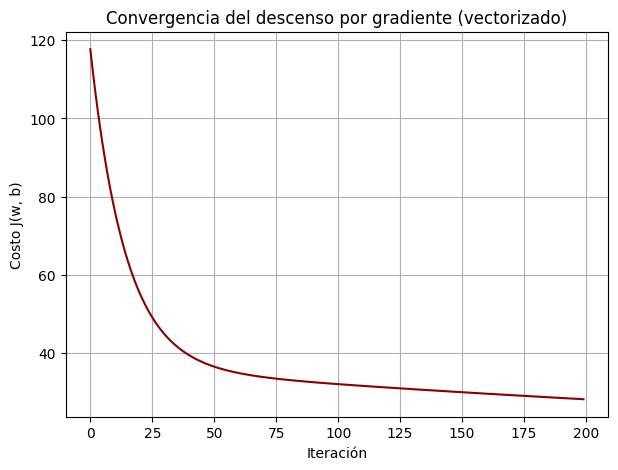

In [39]:
w0, b0 = 0.0, 0.0
alpha = 0.01
num_iters = 200
w_v, b_v, J_hist_v = gradient_descent_vectorized(M, L, w0, b0, alpha, num_iters)
 
plt.figure(figsize=(7,5))
plt.plot(J_hist_v, color='darkred')
plt.xlabel('Iteración')
plt.ylabel('Costo J(w, b)')
plt.title('Convergencia del descenso por gradiente (vectorizado)')
plt.grid(True)
plt.show()

# 9. Experimentos con Learning Rate
 
Se realizan experimentos con al menos tres valores distintos de tasa de aprendizaje ($\alpha$), reportando los parámetros finales y la pérdida obtenida. Esto permite comparar la velocidad y estabilidad de la convergencia.

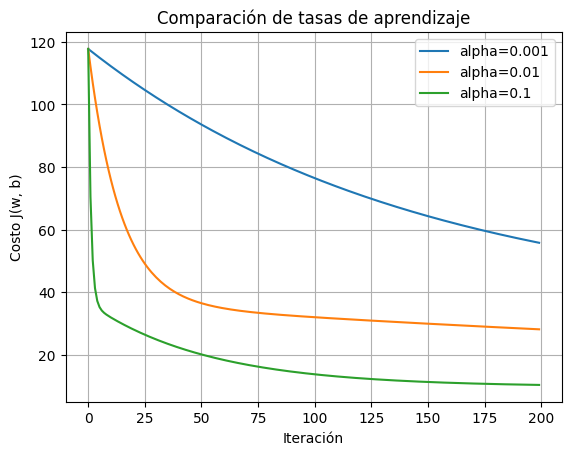

alpha=0.001 | w=3.1662 | b=1.3899 | J_final=55.7956
alpha=0.010 | w=7.9576 | b=0.0086 | J_final=28.1608
alpha=0.100 | w=16.2972 | b=-13.7982 | J_final=10.4024


In [40]:
learning_rates = [0.001, 0.01, 0.1]
num_iters = 200
results = []
for alpha in learning_rates:
    w_exp, b_exp, J_hist_exp = gradient_descent_vectorized(M, L, 0.0, 0.0, alpha, num_iters)
    results.append({'alpha': alpha, 'w': w_exp, 'b': b_exp, 'J': J_hist_exp[-1]})
    plt.plot(J_hist_exp, label=f'alpha={alpha}')
 
plt.xlabel('Iteración')
plt.ylabel('Costo J(w, b)')
plt.title('Comparación de tasas de aprendizaje')
plt.legend()
plt.grid(True)
plt.show()
 
for res in results:
    print(f"alpha={res['alpha']:.3f} | w={res['w']:.4f} | b={res['b']:.4f} | J_final={res['J']:.4f}")

# 10. Ajuste Final
 
Se grafica la recta ajustada sobre los datos originales utilizando los parámetros óptimos obtenidos por descenso por gradiente. Se discuten posibles errores sistemáticos y la calidad del ajuste.

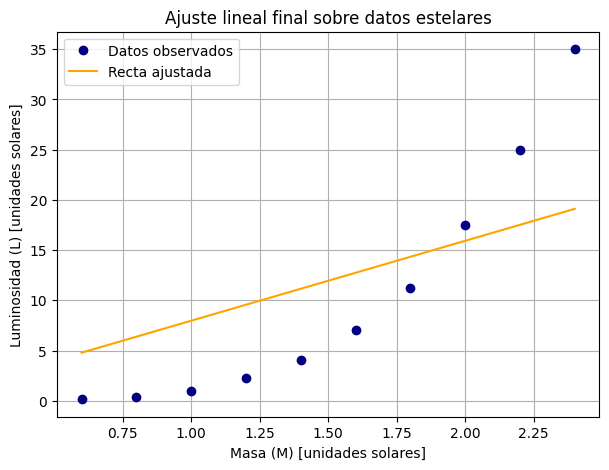

In [41]:
w_final, b_final, _ = gradient_descent_vectorized(M, L, 0.0, 0.0, 0.01, 200)
L_pred = predict(M, w_final, b_final)
 
plt.figure(figsize=(7,5))
plt.plot(M, L, 'o', label='Datos observados', color='navy')
plt.plot(M, L_pred, '-', label='Recta ajustada', color='orange')
plt.xlabel('Masa (M) [unidades solares]')
plt.ylabel('Luminosidad (L) [unidades solares]')
plt.title('Ajuste lineal final sobre datos estelares')
plt.legend()
plt.grid(True)
plt.show()

**Discusión sobre el ajuste:**
 
La recta ajustada aproxima la tendencia general de los datos, aunque se observan desviaciones sistemáticas para masas altas, lo que indica que el modelo lineal no captura completamente la relación física subyacente.

# 11. Preguntas Conceptuales
 
**1. ¿Cuál es el significado físico del parámetro $w$ en el modelo?**
 
El parámetro $w$ representa la tasa de cambio de la luminosidad respecto a la masa estelar. Físicamente, indica cuánto aumenta la luminosidad por cada unidad adicional de masa. En el contexto astrofísico, $w$ aproxima la sensibilidad de la luminosidad a variaciones en la masa, aunque la relación real suele ser no lineal.
 
**2. ¿Cuáles son las limitaciones del modelo lineal aplicado a este problema?**
 
- La relación masa-luminosidad en estrellas suele seguir una ley de potencia ($L \propto M^k$), no una recta.
- El modelo lineal puede subestimar o sobreestimar la luminosidad para masas extremas.
- No captura efectos físicos complejos como composición química, edad o evolución estelar.
- Es útil como aproximación inicial y para ilustrar conceptos matemáticos, pero no describe completamente la física estelar real.